In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
from scipy import stats
import scanpy as sc
import numpy as np
import pandas as pd
from sklearn.neighbors import NearestNeighbors
import anndata
import sys 
sys.path.append('/home/shuonan.chen/scratch_shuonan/code/LCNE_transcriptomics/code/')
import plotting,utils, processing
allmeshes = utils.load_mesh()

In [2]:
import matplotlib.font_manager as fm
import os
font_path = '/home/shuonan.chen/miniconda3/envs/allensdk/lib/python3.8/site-packages/matplotlib/mpl-data/fonts/ttf/Helvetica.ttc'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
plt.rcParams['font.family']      = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica']

In [3]:
adata_foo = sc.read_h5ad("/home/shuonan.chen/scratch_shuonan//LC_scRNAseq/conversion_files/snRNAseq_LCNE_BN_d4.h5ad")
adata_sc = anndata.AnnData(adata_foo.layers['BN'])
adata_sc.obs = adata_foo.obs.copy()
adata_sc.obsm = adata_foo.obsm.copy()
adata_sc.var = adata_foo.var.copy()

filename = '/allen/aind/scratch/shuonan.chen/code/pons_merfish_pipeline/processing/data/adata_mer_subset_2_6k.h5ad'
adata_mer = sc.read_h5ad(filename)
var_names = adata_mer.var_names.intersection(adata_sc.var_names)
adata_mer = adata_mer[:,var_names]  # 314 genes 
adata_mer = adata_mer[adata_mer.obs['leiden']!='5',:]

import trimesh
mesh_LC = trimesh.load_mesh("/allen/aind/scratch/shuonan.chen/scripts/Pons_MERFISH/mesh/LC_ccf_v1_250102 2.obj")
all_spatial= adata_mer.obsm['spatial']
all_spatial = processing.get_hemi(all_spatial, mesh_LC)    
all_spatial*= 25

In [4]:
filename = '/allen/aind/scratch/shuonan.chen/retroseqdata/retroseq_updated_filtered.h5ad'
adata_retro = sc.read_h5ad(filename)
adata_retro.X.shape, adata_retro.X.max()
adata_retro = adata_retro[~(adata_retro.obs['injection_site']=='thalamus')]
gene_len = pd.read_csv(
    "https://raw.githubusercontent.com/chenlingantelope/HarmonizationSCANVI/master/data/gene_len.txt",
    delimiter=" ",header=None,index_col=0,)

gene_len = gene_len.reindex(adata_retro.var.index).dropna()
adata_retro = adata_retro[:, gene_len.index]
assert (adata_retro.var.index == gene_len.index).sum() == adata_retro.shape[1]

adata_retro.X = adata_retro.X / gene_len[1].values * np.median(gene_len[1].values)
adata_retro.X = np.rint(adata_retro.X)
adata_retro.raw = adata_retro.copy()

/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/anndata/_core/storage.py:48: FutureWarning: AnnData previously had undefined behavior around matrices of type <class 'scipy.sparse._coo.coo_matrix'>.In 0.12, passing in this type will throw an error. Please convert to a supported type.Continue using for this minor version at your own risk.
  warnings.warn(msg, FutureWarning)


In [5]:
import sys
sys.path.append('/home/shuonan.chen/scratch_shuonan/code/pons_merfish_pipeline/processing/func/')
from imputations import *

In [6]:
common_genes = np.intersect1d(adata_mer.var_names, adata_retro.var_names)
print(common_genes.shape)
adata_retro_ref = adata_retro[:, common_genes].copy()  # we will impute based on this guy, number of `union_genes=2184` will be imputed. 


(291,)


In [7]:
X_retro = adata_retro_ref[:,common_genes].X
X_mer = adata_mer[:,common_genes].X     

X_retro_norm = processing.normalize_cols(X_retro, ranked=True)
X_mer_norm = processing.normalize_cols(X_mer, ranked=True)

In [39]:
k = 10 # num of neighbors

from sklearn.neighbors import NearestNeighbors
nbrs = NearestNeighbors(n_neighbors=k, metric='euclidean').fit(X_retro_norm)
distances, indices = nbrs.kneighbors(X_mer_norm) # distance: size (N_retro, K)

epsilon = 1e-10
weights = 1 / (distances + epsilon)
weights = weights / weights.sum(axis=1, keepdims=True)  # normalize so that weights sum to 1

In [40]:
weights.shape

(2252, 10)

In [41]:
all_spatial= adata_mer.obsm['spatial']
all_projections= adata_retro.obs['injection_site']
all_spatial = processing.get_hemi(all_spatial, mesh_LC)    
all_spatial *=25

In [42]:
from collections import Counter

In [43]:
imputed_proj =[]
for i in range(adata_mer.n_obs):
    neighbor_idx = indices[i]   
    counts = Counter(np.array(all_projections[neighbor_idx]))
    imputed_proj.append(counts.most_common(1)[0][0])

/scratch/fast/1339261/ipykernel_3757170/502206349.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  counts = Counter(np.array(all_projections[neighbor_idx]))


In [44]:
counts

Counter({'spinal cord': 4, 'frontal cortex': 3, 'cerebellum': 3})

In [45]:
np.unique(imputed_proj)

array(['cerebellum', 'frontal cortex', 'spinal cord'], dtype='<U14')

In [46]:
allmeshes = utils.load_mesh()

In [47]:
np.unique(imputed_proj)

array(['cerebellum', 'frontal cortex', 'spinal cord'], dtype='<U14')

In [48]:
import matplotlib.colors as mcolors
mcolors.TABLEAU_COLORS

{'tab:blue': '#1f77b4',
 'tab:orange': '#ff7f0e',
 'tab:green': '#2ca02c',
 'tab:red': '#d62728',
 'tab:purple': '#9467bd',
 'tab:brown': '#8c564b',
 'tab:pink': '#e377c2',
 'tab:gray': '#7f7f7f',
 'tab:olive': '#bcbd22',
 'tab:cyan': '#17becf'}

In [49]:
fig_path = '/home/shuonan.chen/scratch_shuonan/fig_making_LCNE/june_2025/'
plt.rcParams.update({
    "svg.fonttype": 'none',
    "pdf.fonttype": 42,
    'ps.fonttype':42
})


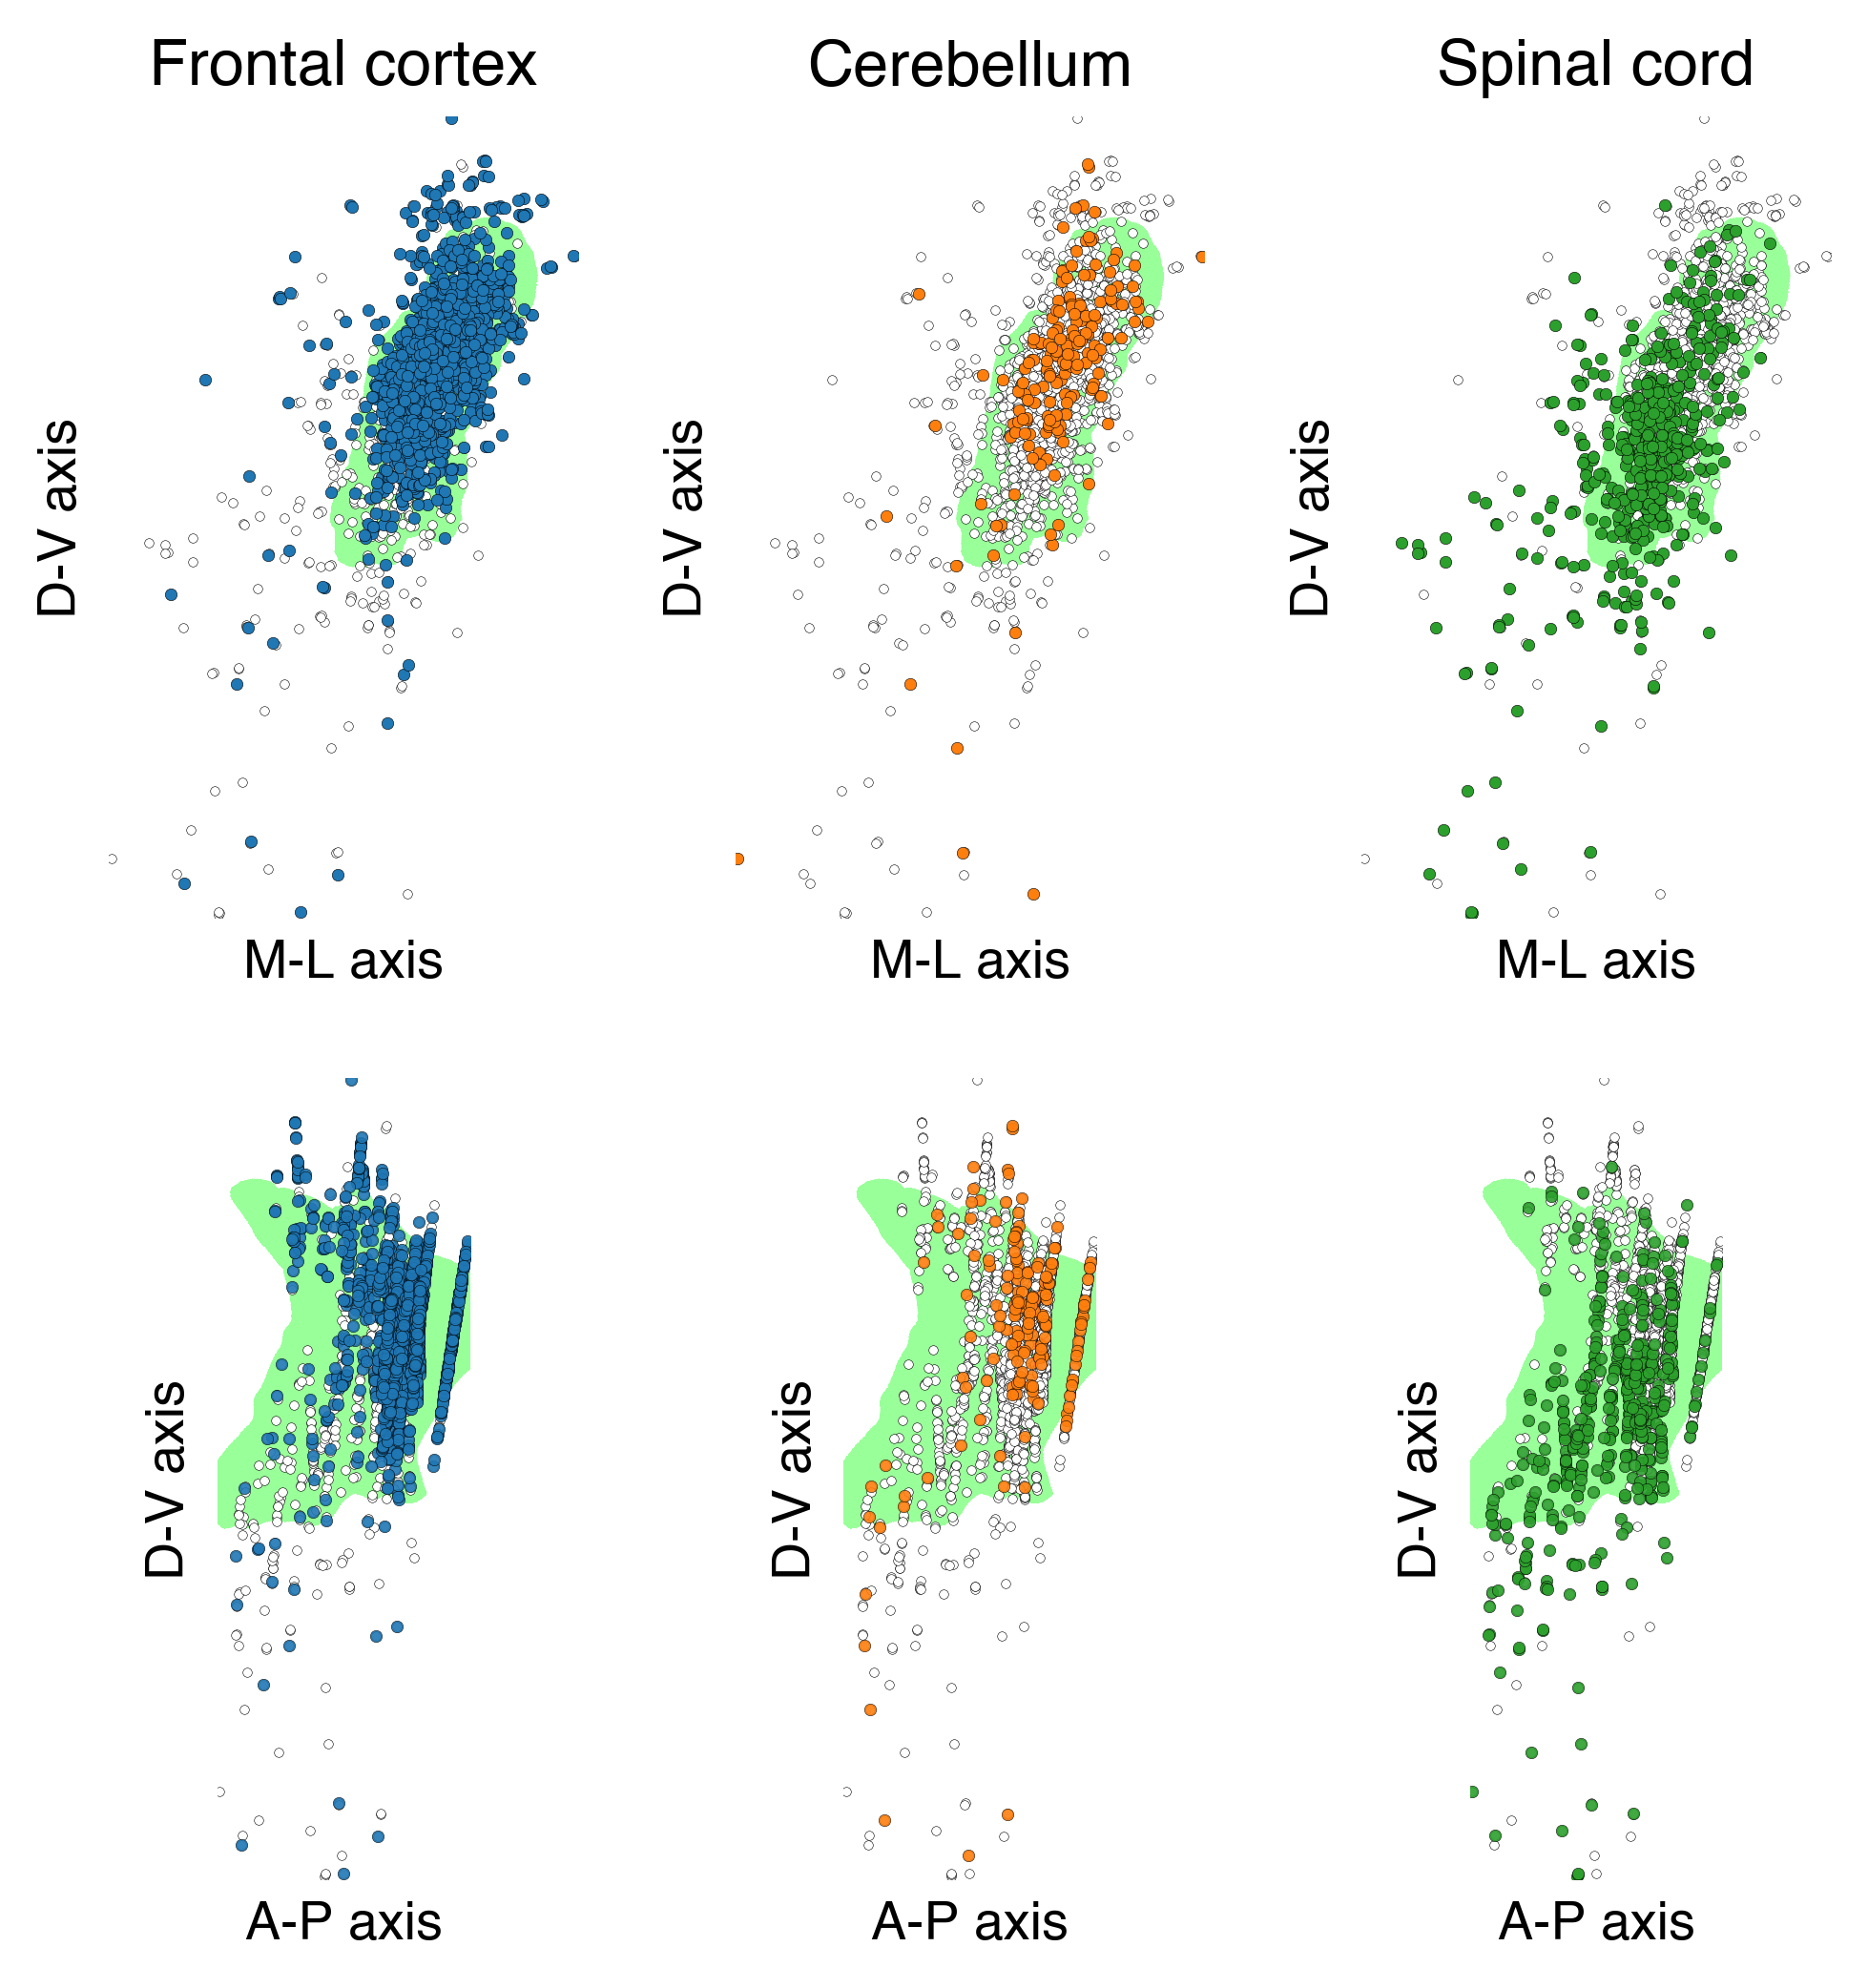

In [50]:
margin = 10
collist = []
s =5
fig, axes = plt.subplots(2,3,figsize = (6,6))
for m,k in enumerate(['frontal cortex','cerebellum','spinal cord']):
    ax = axes[0,m]
    plotting.plot_mesh(ax, allmeshes,direction = 'c',meshcol='lime')
    ax.scatter(all_spatial[:,2],all_spatial[:,1], 
               s=3, alpha = 1, label =k, color = 'white',edgecolor='k',linewidth = .1,)
    ax.scatter(all_spatial[np.array(imputed_proj)==k,2],all_spatial[np.array(imputed_proj)==k,1], 
               s=s, alpha = 1, label =k, color = list(mcolors.TABLEAU_COLORS.values())[m],
              edgecolor='k',linewidth = .1,)
    ax.set_title(k.capitalize())
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xlim(all_spatial[:,2].min()-margin,all_spatial[:,2].max()+margin)
    ax.set_ylim(all_spatial[:,1].max()+margin,all_spatial[:,1].min()-margin)
    ax.set_yticks([]);ax.set_ylabel('D-V axis')
    ax.set_xticks([]);ax.set_xlabel('M-L axis')
    
    ax = axes[1,m]
    plotting.plot_mesh(ax, allmeshes,direction = 's',meshcol='lime')
    ax.scatter(all_spatial[:,0],all_spatial[:,1], 
               s=3, alpha = 1, label =k, color = 'white',edgecolor='k',linewidth = .1,)
    ax.scatter(all_spatial[np.array(imputed_proj)==k,0],all_spatial[np.array(imputed_proj)==k,1], 
               s=s, alpha = .9, label =k,color = list(mcolors.TABLEAU_COLORS.values())[m],
              edgecolor='k',linewidth = .1,)
    
    ax.set_xlim(all_spatial[:,0].min()-margin,all_spatial[:,0].max()+margin)
    ax.set_ylim(all_spatial[:,1].max()+margin,all_spatial[:,1].min()-margin)
    ax.set_yticks([]);ax.set_ylabel('D-V axis')
    ax.set_xticks([]);ax.set_xlabel('A-P axis')
    for spine in ax.spines.values():
        spine.set_visible(False)

plt.gcf().set_dpi(400) 
# plt.savefig(fig_path+"merfish_projections.svg", format="svg")   